In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import adiabatic_approx_func as adprox

In [277]:
L = 500
taus = np.logspace(-3,3,200)

states = [state(L,tau,tau) for tau in taus]
def defect_exact(n,state):
    return 1/2- Px(n,state)
def defect_approx(n,tau):
    return 1/2 - adprox.P_n(n,tau)


In [278]:
# allocate grid
ns = np.arange(1,13+1)

f_exact = np.zeros((len(ns), len(taus)))   # shape (Nn , Nt)

# fill grid
for i, n in (enumerate(tqdm(ns))):
    for j, st in enumerate(states):
        f_exact[i,j] = defect_exact(n, st)


  0%|          | 0/13 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_3740/3220210470.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  f_exact[i,j] = defect_exact(n, st)
100%|██████████| 13/13 [05:38<00:00, 26.06s/it]


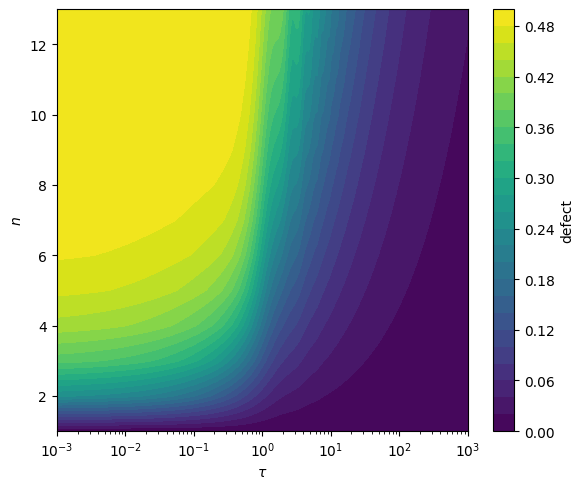

In [281]:
import matplotlib.pyplot as plt

N, T = f_exact.shape   # N = len(n_vals), T = len(tau_vals)

plt.figure(figsize=(6,5))
cp = plt.contourf(taus, ns, f_exact, levels=30)

plt.xlabel(r'$\tau$')
plt.ylabel(r'$n$')
plt.xscale('log')
plt.colorbar(cp, label='defect')

plt.tight_layout()
plt.show()


In [263]:
# allocate grid
f_approx = np.zeros((len(ns), len(taus)))   # shape (Nn , Nt)

# fill grid
for i, n in enumerate(ns):
    for j, tau in enumerate(taus):
        f_approx[i,j] = defect_approx(n, tau)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_3740/1994325128.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  f_approx[i,j] = defect_approx(n, tau)


TypeError: Length of x (200) must match number of columns in z (100)

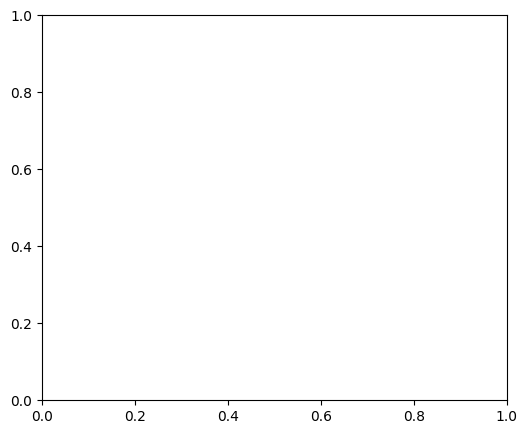

In [280]:
import matplotlib.pyplot as plt

N, T = f_approx.shape   # N = len(n_vals), T = len(tau_vals)

plt.figure(figsize=(6,5))
cp = plt.contourf(taus, ns, f_approx, levels=30)

plt.xlabel(r'$\tau$')
plt.ylabel(r'$n$')
plt.xscale('log')
plt.colorbar(cp, label='defect')

plt.tight_layout()
plt.show()


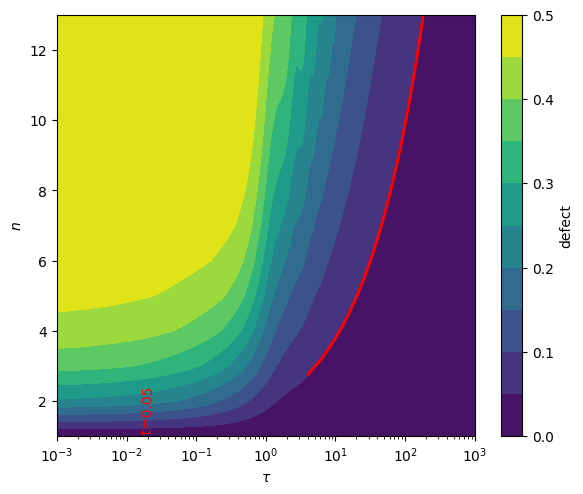

In [338]:
level = .05  # choose your constant value f(n,τ)=level

plt.figure(figsize=(6,5))
cp = plt.contourf(taus, ns, f_exact, levels=10)
#plt.yscale("log")
#plt.xscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$n$")

# draw the constant-defect line
cs = plt.contour(taus, ns, f_exact,levels=[level],colors="red", linewidths=2)

# optional label on the contour
plt.clabel(cs, fmt={level: f"defect={level}"})
plt.colorbar(cp, label='defect')
plt.tight_layout()

xscale("log")

plt.show()


plot xlim = (np.float64(0.03162277660168379), np.float64(31.622776601683793))


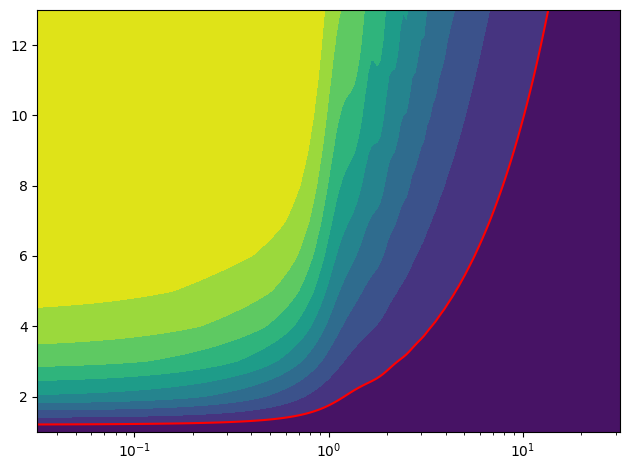

In [339]:
plt.figure()
plt.contourf(taus**(1/2), ns, f_exact, levels=10)
plt.contour(taus**(1/2), ns, f_exact, levels=[level], colors="red")
plt.xscale("log")
plt.tight_layout()
print("plot xlim =", plt.xlim())
plt.show()


In [353]:
level = 0.4
coords = []   # will store (tau, n)

for i, n in enumerate(ns):
    values = f_exact[i]          # f(n, τ_j) for all τ
    for j in range(len(taus) - 1):
        v1 = values[j]
        v2 = values[j+1]

        # check if the level lies between v1 and v2
        if (v1 - level) * (v2 - level) <= 0:   # crossing or touching
            # linear interpolation in τ
            t1 = taus[j]
            t2 = taus[j+1]
            if v1 == v2:
                tau_cross = t1
            else:
                tau_cross = t1 + (level - v1) * (t2 - t1) / (v2 - v1)

            coords.append((tau_cross, n))


In [354]:
coords = []

# # horizontal crossings (fixed n)
# for i in range(len(ns)):
#     for j in range(len(taus)-1):
#         v1 = f_exact[i, j]
#         v2 = f_exact[i, j+1]
#         if (v1 - level) * (v2 - level) <= 0:
#             t1, t2 = taus[j], taus[j+1]
#             if v1 == v2:
#                 tau_cross = t1
#             else:
#                 tau_cross = t1 + (level - v1) * (t2 - t1) / (v2 - v1)
#             coords.append((tau_cross, ns[i]))

# vertical crossings (fixed τ)
for j in range(len(taus)):
    for i in range(len(ns)-1):
        v1 = f_exact[i, j]
        v2 = f_exact[i+1, j]
        if (v1 - level) * (v2 - level) <= 0:
            tau_cross = taus[j]
            if v1 == v2:
                n_cross = ns[i]
            else:
                n_cross = ns[i] + (level - v1) * (ns[i+1] - ns[i]) / (v2 - v1)
            coords.append((tau_cross, n_cross))


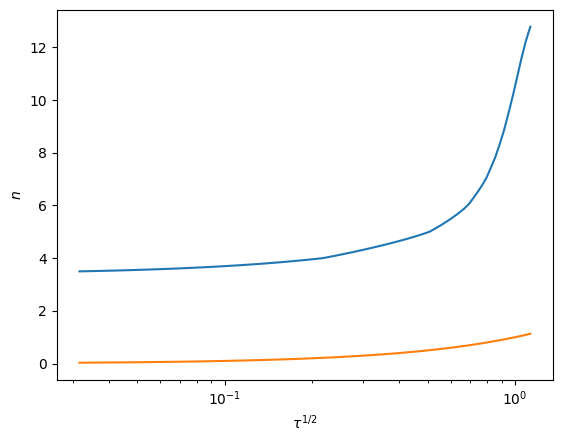

In [355]:
x = array([coord[1] for coord in coords])
y = array([coord[0] for coord in coords])

plot(y**(1/2),x)

plot(y**0.5,y**0.5)

xlabel(r"$\tau^{1/2}$")
ylabel(r"$n$")
#xlim(y[0]**(1/2),y[-1]**(1/2))
xscale("log")
#yscale("log")